# House Prices Project
## Saleh Ali Mohamed & Bilal Haddad
**Dataset**: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

**Goal**: Predict the sale price of houses using statistical and machine learning methods.


---
## Setup and Imports

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm #for ANOVA
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', 100)
%matplotlib inline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler




## Load Data

In [131]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')


print(f'Training set: {train.shape[0]} rows, {train.shape[1]} columns')
print(f'Test set: {test.shape[0]} rows, {test.shape[1]} columns')

train.head()

Training set: 1460 rows, 81 columns
Test set: 1459 rows, 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0000,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0000,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


count     1460.0000
mean    180921.1959
std      79442.5029
min      34900.0000
25%     129975.0000
50%     163000.0000
75%     214000.0000
max     755000.0000
Name: SalePrice, dtype: float64


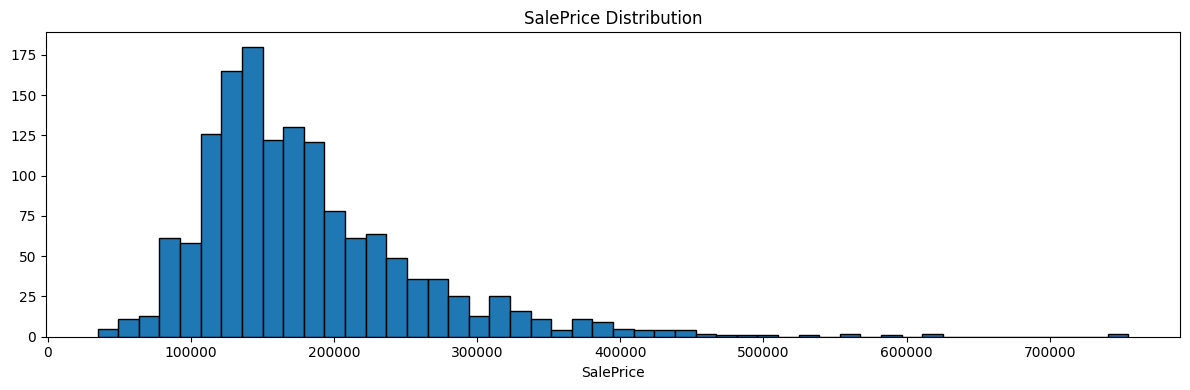

Skewness: 1.883


In [132]:
# Explore the target variable
print(train['SalePrice'].describe())

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(train['SalePrice'], bins=50, edgecolor='black')
axes.set_title('SalePrice Distribution')
axes.set_xlabel('SalePrice')
plt.tight_layout()
plt.show()

print(f'Skewness: {train["SalePrice"].skew():.3f}')

# y-axis: Number of houses | x-axis: Price (e.g., 100 houses at 150k)

# Skewness:
# If skewness = 0: Perfect bell curve (symmetrical)
# If skewness > 0: Right-skewed (tail extends to the right)
# If skewness < 0: Left-skewed (tail extends to the left)

# Note: Bell curve width = Standard Deviation
# A distribution is "centered" if its mean equals 0
# Affiche le résumé de toutes les variables



## Fixing the Skewed Data

`SalePrice` is severely right-skewed.The expensive houses are dragging out the right tail, which is a huge problem. If we leave the data like this, it completely breaks the normality assumptions we need for standard parametric models like OLS regression.

The easiest way to fix that, is a log transformation. We used `np.log1p`. 

### Why take the log?

* **Asymmetric compression:** Logarithms are non-linear. They aggressively shrink those massive outlier prices while barely touching the lower-end values.
* **Stabilizing variance:** By pulling extreme values back toward the median, we naturally reduce the right-skew and even out the variance.
* **Forcing normality:** The entire goal is to massage this skewed distribution into something resembling a Gaussian bell curve. Our linear models in Part 4 absolutely depend on this to perform well.

**The Result:** Check out the comparison below. The transformation did exactly what we needed it to do by flattening the right tail. Those extreme high-value outliers are minimized, leaving us with a clean, symmetric distribution that is actually ready for statistical modeling.

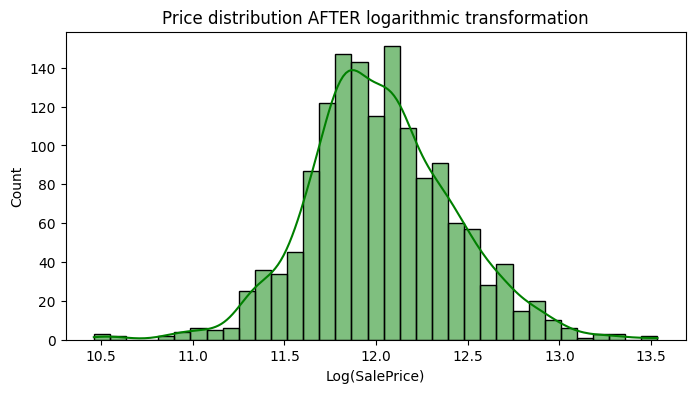

Skewness: 0.121


In [133]:
#Visualize the distribution of the variable (SalePrice) after log transformation
plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(train['SalePrice']), kde=True, color='green')
plt.title("Price distribution AFTER logarithmic transformation")
plt.xlabel("Log(SalePrice)")
plt.show()
print(f'Skewness: {np.log1p(train["SalePrice"]).skew():.3f}')

As you can see, the log-transformation works very well. It "normalizes" the distribution by compressing the long right tail. It pulls those super expensive outlier houses toward the center, creating a much more symmetric, bell-shaped curve. This is exactly what we need becauseit stabilizes the variance.

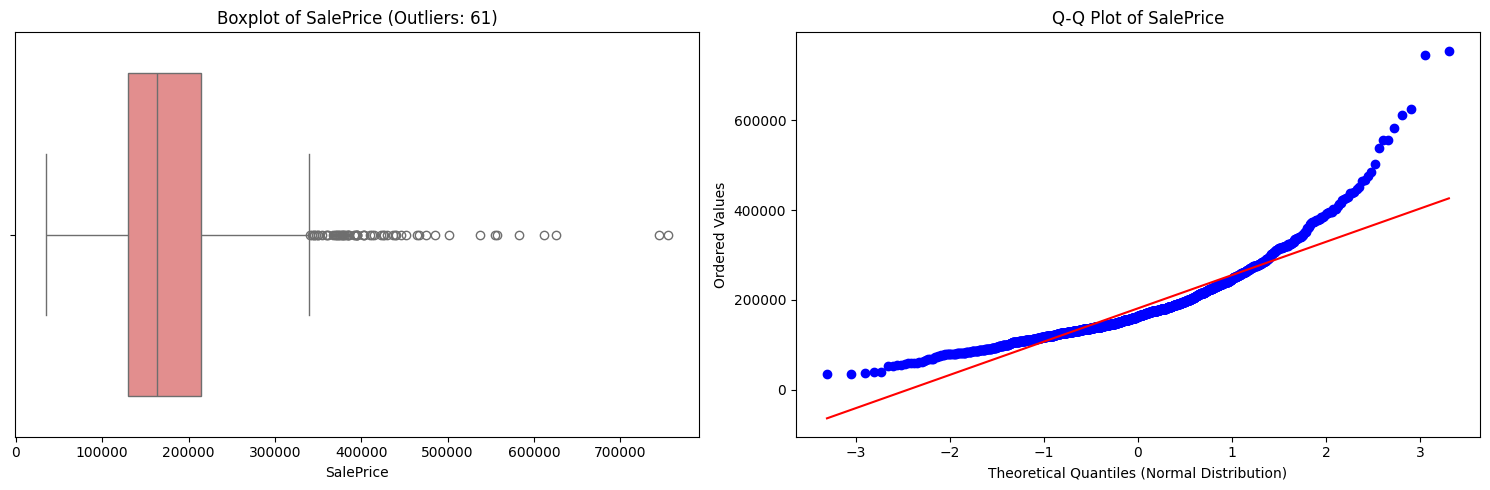

In [134]:

Q1 = train['SalePrice'].quantile(0.25) # Calculate first quartile (Q1)
Q3 = train['SalePrice'].quantile(0.75) # Calculate third quartile (Q3)
IQR = Q3 - Q1 # Calculate interquartile range (IQR)
num_outliers = ((train['SalePrice'] < (Q1 - 1.5 * IQR)) | (train['SalePrice'] > (Q3 + 1.5 * IQR))).sum() # Count the number of outliers 

# Create the figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left plot : Boxplot with outliers count in the title
sns.boxplot(x=train['SalePrice'], color='lightcoral', ax=axes[0])
axes[0].set_title(f'Boxplot of SalePrice (Outliers: {num_outliers})')
axes[0].set_xlabel('SalePrice')

# Right plot : Q-qplot
stats.probplot(train['SalePrice'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of SalePrice')
axes[1].set_ylabel('Ordered Values')
axes[1].set_xlabel('Theoretical Quantiles (Normal Distribution)')

plt.tight_layout()
plt.show()

The Boxplot (Left): You can see the main "box" representing the bulk of the data is completely squished to the left. Then there is this massive trail of 61 outliers stretching out on the right.

The Q-Q Plot (Right): If our house prices were normally distributed, all those blue dots would be around the red diagonal line. Instead, some of the dots are shoot straight up on the right side.

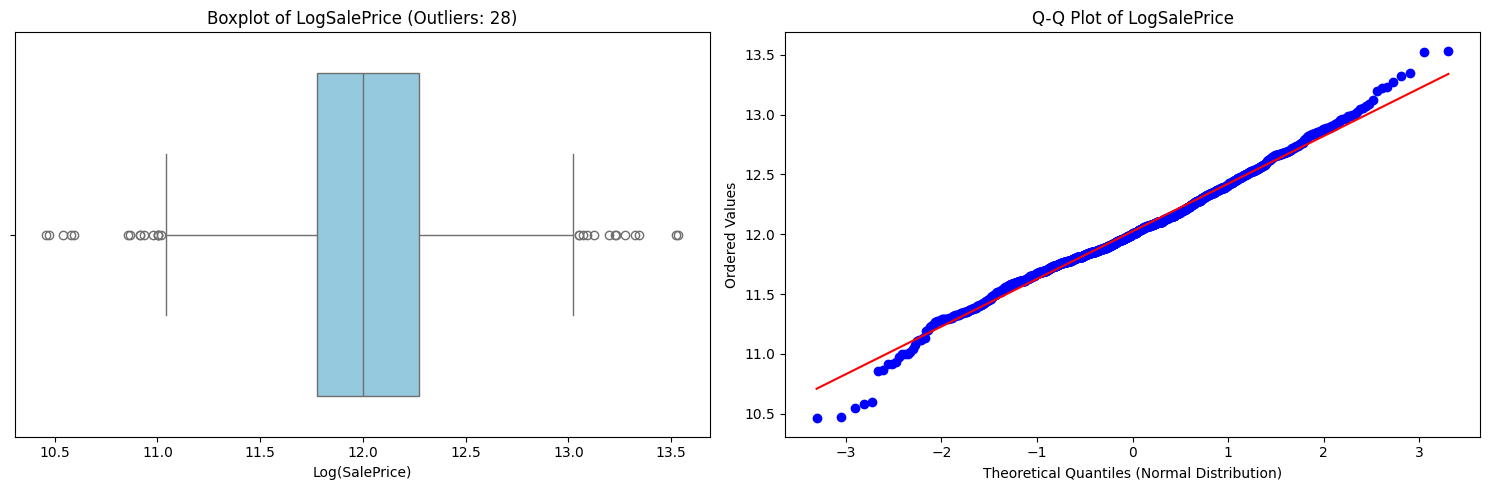

In [135]:
train['LogSalePrice'] = np.log(train['SalePrice']) # tranform the saleprice variable into log(saleprice) to reduce skewness.

# 2. Calculate quartiles and IQR for LogSalePrice
Q1_log = train['LogSalePrice'].quantile(0.25)
Q3_log = train['LogSalePrice'].quantile(0.75)
IQR_log = Q3_log - Q1_log
num_outliers_log = ((train['LogSalePrice'] < (Q1_log - 1.5 * IQR_log)) | 
                    (train['LogSalePrice'] > (Q3_log + 1.5 * IQR_log))).sum()

# 3. Create the figure (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Boxplot
sns.boxplot(x=train['LogSalePrice'], color='skyblue', ax=axes[0])
axes[0].set_title(f'Boxplot of LogSalePrice (Outliers: {num_outliers_log})')
axes[0].set_xlabel('Log(SalePrice)')

# Plot 2: Q-Q Plot
stats.probplot(train['LogSalePrice'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of LogSalePrice')
axes[1].set_ylabel('Ordered Values')
axes[1].set_xlabel('Theoretical Quantiles (Normal Distribution)')

plt.tight_layout()
plt.show()

These are the same plot as before but with log transformation.We can clearly see that the data is in much better shape now.

The Boxplot (Left): Everything is finally centered. The median sits right in the middle of the box, and the whisk The total number of outliers dropped from 61 down to 28. Those remaining outliers are now spread across both the high and low ends instead of just dragging out the right side.

The Q-Q Plot (Right): This is the proof. The blue dots follow the red normal line pretty well now. We can spot a tiny bit of deviation at upper and lower tails, but that's not a problem.

---
## Part 1: Classical Statistical Inference

Apply basic statistical methods to explore the data:
- **Sample mean and variance** of `SalePrice` and key features
- **Confidence intervals** for the mean SalePrice
- **Hypothesis testing** — e.g. is the mean SalePrice significantly different from \$180,000?
- Visualize distributions and support your conclusions with plots

In [136]:
# Let's analyze the sample statistics and variance for SalePrice and key features
# like GrLivArea, OverallQual, LotArea, and YearBuilt.

def classical_statistical_inference(data, column_name = 'SalePriceLog'):
    if column_name == 'SalePriceLog' :
        sample_mean = np.log1p(data['SalePrice'].mean())
        variance = np.log1p(data['SalePrice'].var())
        std_dev = np.log1p(data['SalePrice'].std()) # Square root of variance
        n = len(data['SalePrice'])

    else :
        sample_mean = data[column_name].mean()
        variance = data[column_name].var()
        std_dev = data[column_name].std() # Square root of variance
        n = len(data[column_name])


    se = stats.sem(data[column_name])   # Standard Error of the Mean (SEM)

    # 95% Confidence Interval
    # Note: For n > 30, the Student's t-distribution closely resembles the Normal distribution.
    # However, since we are estimating the mean using the sample standard deviation (s)
    # rather than the population parameter (sigma), the t-distribution is preferred.
    interval_95 = stats.t.interval(0.95, n-1, loc=sample_mean, scale = se)

    # 99% Confidence Interval
    interval_99 = stats.t.interval(0.99, n-1, loc=sample_mean, scale = se)

    print(f"--- Analysis of {column_name} ---")
    print(f"Mean: {sample_mean:.2f}")
    print(f"Variance: {variance:.2f}")
    print(f"Standard Deviation: {std_dev:.2f}")
    print(f"95% Confidence Interval: [{interval_95[0]:.2f}, {interval_95[1]:.2f}]")
    print(f"99% Confidence Interval: [{interval_99[0]:.2f}, {interval_99[1]:.2f}]")
    print("\n")

# CRUCIAL : On crée la colonne manquante pour éviter le KeyError lors de l'appel par défaut
train['SalePriceLog'] = np.log1p(train['SalePrice'])


classical_statistical_inference(train, 'GrLivArea') # Analyzing GrLivArea (Above grade/ground living area square feet)
classical_statistical_inference(train, 'OverallQual') # Analyzing OverallQual (Rates the overall material and finish of the house from 1 to 10)
classical_statistical_inference(train, 'LotArea') # Analyzing LotArea (High variance suggests a mix of small and large plots)
classical_statistical_inference(train, 'YearBuilt') # Analyzing YearBuilt (Low variance would suggest the housing stock was built around the same time)
classical_statistical_inference(train, 'TotalBsmtSF')
classical_statistical_inference(train, 'SalePrice') # Analyzing SalePrice (Target variable)
classical_statistical_inference(train) # Utilise maintenant 'SalePriceLog' par défaut sans erreur

# These key features were selected as potentially relevant indicators.
# While the confidence interval was specifically requested for SalePrice,
# I applied it to all features to provide a broader statistical overview.

--- Analysis of GrLivArea ---
Mean: 1515.46
Variance: 276129.63
Standard Deviation: 525.48
95% Confidence Interval: [1488.49, 1542.44]
99% Confidence Interval: [1479.99, 1550.93]


--- Analysis of OverallQual ---
Mean: 6.10
Variance: 1.91
Standard Deviation: 1.38
95% Confidence Interval: [6.03, 6.17]
99% Confidence Interval: [6.01, 6.19]


--- Analysis of LotArea ---
Mean: 10516.83
Variance: 99625649.65
Standard Deviation: 9981.26
95% Confidence Interval: [10004.42, 11029.24]
99% Confidence Interval: [9843.08, 11190.57]


--- Analysis of YearBuilt ---
Mean: 1971.27
Variance: 912.22
Standard Deviation: 30.20
95% Confidence Interval: [1969.72, 1972.82]
99% Confidence Interval: [1969.23, 1973.31]


--- Analysis of TotalBsmtSF ---
Mean: 1057.43
Variance: 192462.36
Standard Deviation: 438.71
95% Confidence Interval: [1034.91, 1079.95]
99% Confidence Interval: [1027.82, 1087.04]


--- Analysis of SalePrice ---
Mean: 180921.20
Variance: 6311111264.30
Standard Deviation: 79442.50
95% Confidenc

The analysis confirms that the logarithmic transformation significantly reduces the variance of the target variable (from ~6.3 billion in the original scale to 0.16 in the log scale). This reduction in variance and the resulting stabilization of the distribution are critical for the reliability of our parametric regression models in Part 4.

### **Hypothesis testing** — e.g. is the mean SalePrice significantly different from \$180,000?
$H_0$ : sample_mean = $180,000  //   $H_1$ : sample_mean =! $180,000

In [137]:
#create a list of tuples for the saleprice and log(saleprice)
analysis_targets = [
    ("Raw Sale Price", train['SalePrice'], 180000),
    ("Log Sale Price", np.log1p(train['SalePrice']), np.log1p(180000))
]

# perform the analysis for SalePrice and Log(SalePrice)
for name, data, target_mu in analysis_targets:
    # mean and variance
    mean_val = data.mean()
    variance = data.var()
    
    # 95% Confidence Interval
    ci_low, ci_up = stats.t.interval(
        confidence=0.95, 
        df=len(data)-1, 
        loc=mean_val, 
        scale=stats.sem(data)
    )
    
    # Hypothesis Test
    t_stat, p_value = stats.ttest_1samp(data, popmean=target_mu)
    if p_value < 0.05 : # significance level of 0.05
       decision = "Reject H0"
    else :
       decision = "Fail to Reject H0"

    # Print Results-
    print(f"--- {name.upper()} ---")
    print(f"Mean           : {mean_val:,.4f}")
    print(f"Variance       : {variance:,.4f}")
    print(f"95% Conf. Int. : [{ci_low:,.4f}, {ci_up:,.4f}]")
    print(f"T-statistic    : {t_stat:.4f}")
    print(f"p-value        : {p_value:.4e} ({decision})")
    print("-" * 55)

--- RAW SALE PRICE ---
Mean           : 180,921.1959
Variance       : 6,311,111,264.2974
95% Conf. Int. : [176,842.8410, 184,999.5507]
T-statistic    : 0.4431
p-value        : 6.5778e-01 (Fail to Reject H0)
-------------------------------------------------------
--- LOG SALE PRICE ---
Mean           : 12.0241
Variance       : 0.1596
95% Conf. Int. : [12.0036, 12.0446]
T-statistic    : -7.3331
p-value        : 3.7148e-13 (Reject H0)
-------------------------------------------------------


### Visualize distributions and support your conclusions with plots

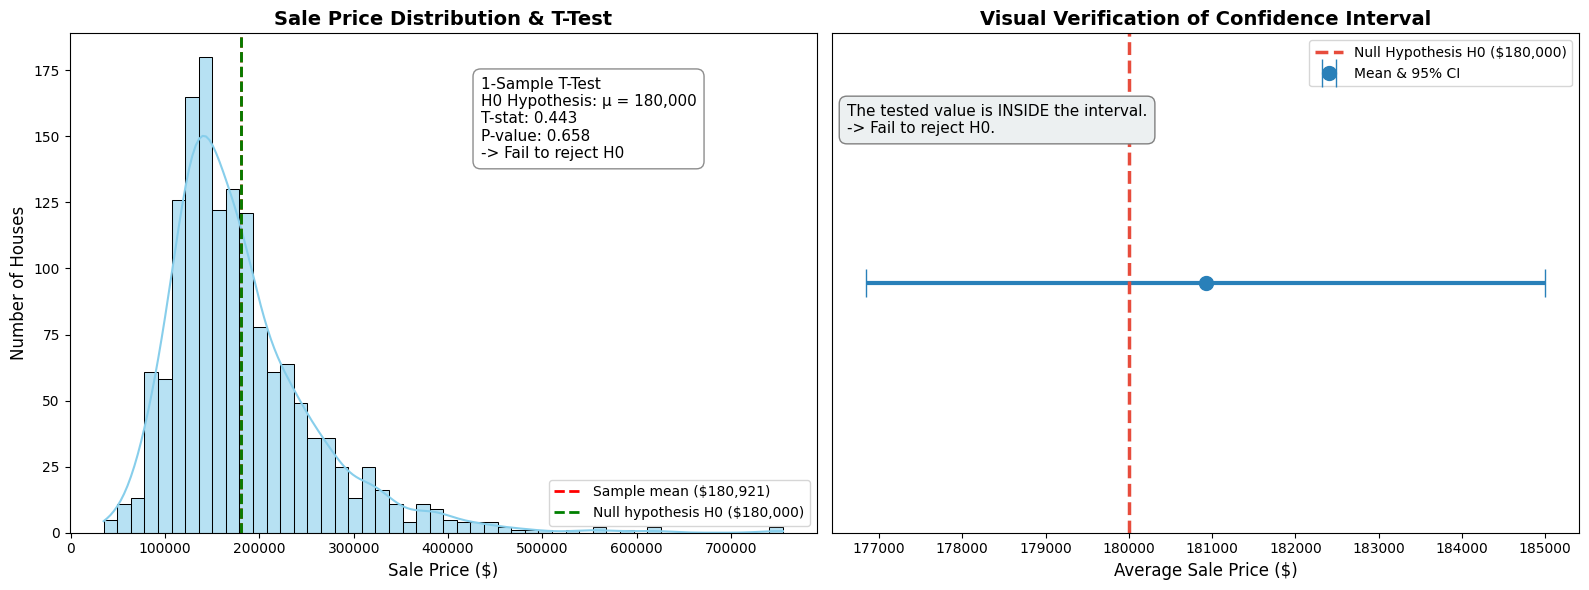

In [138]:

sale_price = train['SalePrice']
mean_price = sale_price.mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
#----------------------------------------
# Right plot : SalePrice distribution
sns.histplot(sale_price, bins=50, kde=True, color='skyblue', alpha=0.6, ax=ax1)

ax1.axvline(mean_price, color='red', linestyle='dashed', linewidth=2,
            label=f"Sample mean (${mean_price:,.0f})")

ax1.axvline(180000, color='green', linestyle='dashed', linewidth=2,
            label=f"Null hypothesis H0 (${180000:,.0f})")

t_stat, p_value = stats.ttest_1samp(a=sale_price, popmean=180000)

stats_text = (f"1-Sample T-Test\n"
              f"H0 Hypothesis: \u03BC = 180,000\n"
              f"T-stat: {t_stat:.3f}\n"
              f"P-value: {p_value:.3f}\n"
              f"-> Fail to reject H0")

ax1.text(0.55, 0.75, stats_text, transform=ax1.transAxes, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

ax1.set_title("Sale Price Distribution & T-Test", fontsize=14, fontweight='bold')
ax1.set_xlabel("Sale Price ($)", fontsize=12)
ax1.set_ylabel("Number of Houses", fontsize=12)
ax1.legend()


# Left plot : Boxplot
#---------------------------------------------

n = len(sale_price)
sem = stats.sem(sale_price) 
ci_95 = stats.t.interval(confidence=0.95, df=n-1, loc=mean_price, scale=sem)

ax2.errorbar(x=mean_price, y=0, xerr=[[mean_price - ci_95[0]], [ci_95[1] - mean_price]], 
             fmt='o', color='#2980b9', markersize=10, capsize=10, linewidth=3, label='Mean & 95% CI')

ax2.axvline(180000, color='#e74c3c', linestyle='--', linewidth=2.5, 
            label=f'Null Hypothesis H0 (${180000:,.0f})')

# delete the y-axis ticks
ax2.set_yticks([]) 
ax2.set_xlabel("Average Sale Price ($)", fontsize=12)
ax2.set_title("Visual Verification of Confidence Interval", fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')

#If 180000 is in the confidence interval, we fail to reject H0. If it's outside, we reject H0.
if ci_95[0] <= 180000 <= ci_95[1]:
    conclusion_text = "The tested value is INSIDE the interval.\n-> Fail to reject H0."
else:
    conclusion_text = "The tested value is OUTSIDE the interval.\n-> Reject H0."

ax2.text(0.02, 0.80, conclusion_text, transform=ax2.transAxes, fontsize=11, 
         bbox=dict(facecolor='#ecf0f1', edgecolor='gray', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

This plot shows the results of our previous T-Test with 1 sample (1-sample T-test).The red-dot line is the sample mean and the green-dot line is the null hypothesis. We can cleary see why we failed to reject the H0 hypothesis the 2 lines are nearly one in antoher.


As we can observe, the value of the null hypothesis ($H_0$) falls within the 95% confidence interval. This result is consistent with our decision to fail to reject $H_0$; the central point represents the calculated mean of our dataset, while the red line indicates the tested value of $H_0$

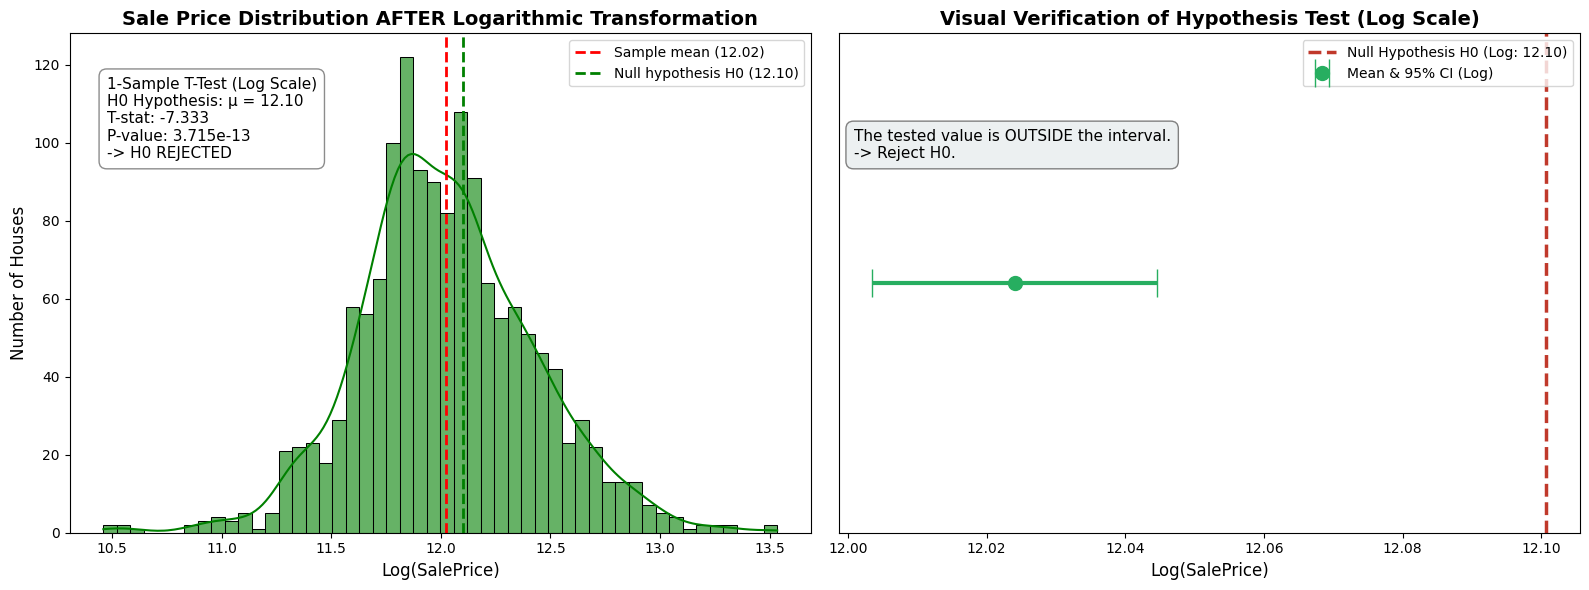

In [139]:
# transform the saleprice variable into log(saleprice)
log_sale_price = np.log1p(train['SalePrice'])
log_sample_mean = log_sale_price.mean()
log_test_value = np.log1p(180000)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
#----------------------------------------
#Right plot : SalePrice distribution
sns.histplot(log_sale_price, bins=50, kde=True, color='green', alpha=0.6, ax=ax1)

ax1.axvline(log_sample_mean, color='red', linestyle='dashed', linewidth=2,
            label=f"Sample mean ({log_sample_mean:.2f})")
ax1.axvline(log_test_value, color='green', linestyle='dashed', linewidth=2,
            label=f"Null hypothesis H0 ({log_test_value:.2f})")

t_stat_log, p_value_log = stats.ttest_1samp(a=log_sale_price, popmean=log_test_value)

if p_value_log < 0.05:
    conclusion_t = "H0 REJECTED"
else:
    conclusion_t = "FAILED TO REJECT H0"

stats_text = (f"1-Sample T-Test (Log Scale)\n"
              f"H0 Hypothesis: \u03BC = {log_test_value:.2f}\n"
              f"T-stat: {t_stat_log:.3f}\n"
              f"P-value: {p_value_log:.3e}\n"
              f"-> {conclusion_t}")

ax1.text(0.05, 0.75, stats_text, transform=ax1.transAxes, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

ax1.set_title("Sale Price Distribution AFTER Logarithmic Transformation", fontsize=14, fontweight='bold')
ax1.set_xlabel("Log(SalePrice)", fontsize=12)
ax1.set_ylabel("Number of Houses", fontsize=12)
ax1.legend()

# Left plot : Boxplot
#---------------------------------------------

n = len(log_sale_price)
log_sem = stats.sem(log_sale_price)
log_ci_95 = stats.t.interval(confidence=0.95, df=n-1, loc=log_sample_mean, scale=log_sem)

# Tracé de la barre d'erreur sur ax2
ax2.errorbar(x=log_sample_mean, y=0, xerr=[[log_sample_mean - log_ci_95[0]], [log_ci_95[1] - log_sample_mean]], 
             fmt='o', color='#27ae60', markersize=10, capsize=10, linewidth=3, label='Mean & 95% CI (Log)')

ax2.axvline(log_test_value, color='#c0392b', linestyle='--', linewidth=2.5, 
            label=f'Null Hypothesis H0 (Log: {log_test_value:.2f})')

#remove some unnecessary y-axis ticks for better visualization
ax2.set_yticks([])
ax2.set_xlabel("Log(SalePrice)", fontsize=12)
ax2.set_title("Visual Verification of Hypothesis Test (Log Scale)", fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')

#If the tested value is in the confidence interval, we fail to reject H0. If it's outside, we reject H0.
if log_ci_95[0] <= log_test_value <= log_ci_95[1]:
    conclusion_ci = "The tested value is INSIDE the interval.\n-> Fail to reject H0."
else:
    conclusion_ci = "The tested value is OUTSIDE the interval.\n-> Reject H0."

ax2.text(0.02, 0.75, conclusion_ci, transform=ax2.transAxes, fontsize=11, 
         bbox=dict(facecolor='#ecf0f1', edgecolor='gray', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

##### **1. Analysis of Raw SalePrice**
Based on the one-sample t-test conducted on the `SalePrice`, we obtained a **t-statistic of 0.4431** and a **p-value of 0.6578**. Since the p-value is significantly higher than the standard threshold of 0.05, we **fail to reject the null hypothesis** ($H_0$). It means that there is no statistically significant difference between the observed sample mean and the hypothesized value of **$180,000**. The observed variation is possibly due to sampling variability.

##### **2. Analysis of log(Saleprice)**
However, when we use **log(Saleprice)**, we obtain a **t-statistic of -7.3272**. As the confidence interval is **[12.0035, 12.0445]**, we **strongly reject the null hypothesis H0** in this case. We can also see on the right plot red dotted line is far away from the confidance internal in green.

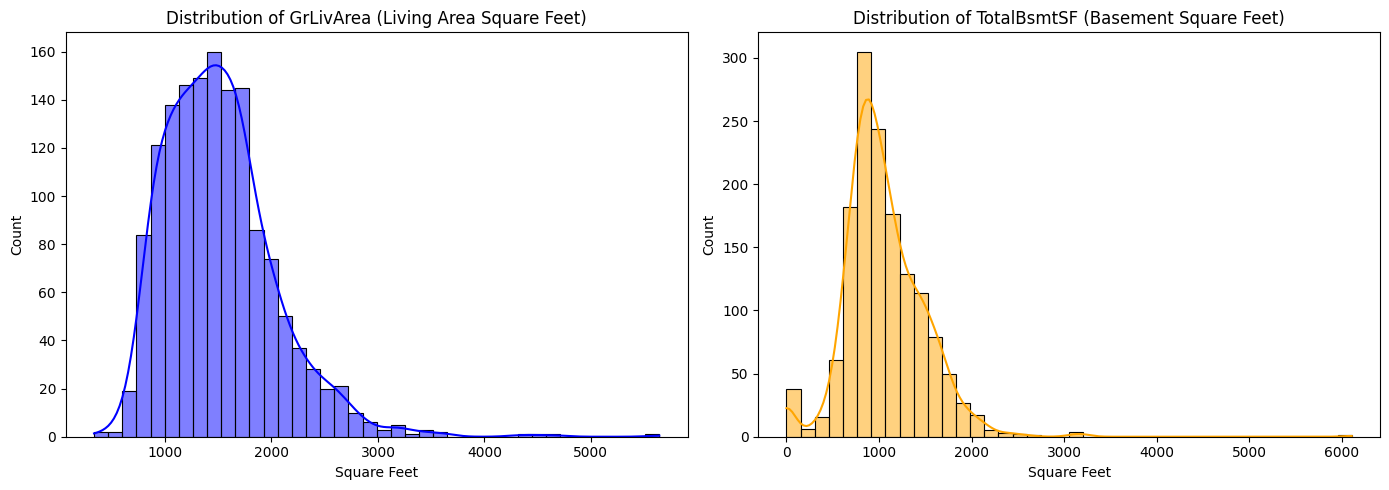

In [140]:
# Distribution of key features: GrLivArea  and TotalBsmtSF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of the living area
sns.histplot(train['GrLivArea'], bins=40, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of GrLivArea (Living Area Square Feet)')
axes[0].set_xlabel('Square Feet')

# Distribution of the basement area
sns.histplot(train['TotalBsmtSF'], bins=40, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of TotalBsmtSF (Basement Square Feet)')
axes[1].set_xlabel('Square Feet')

plt.tight_layout()
plt.show()

These plots shows that the skewness problem is not only on the `SalePrice` variable but also on others like, `TotalBsmtSF` and `GrLivArea`

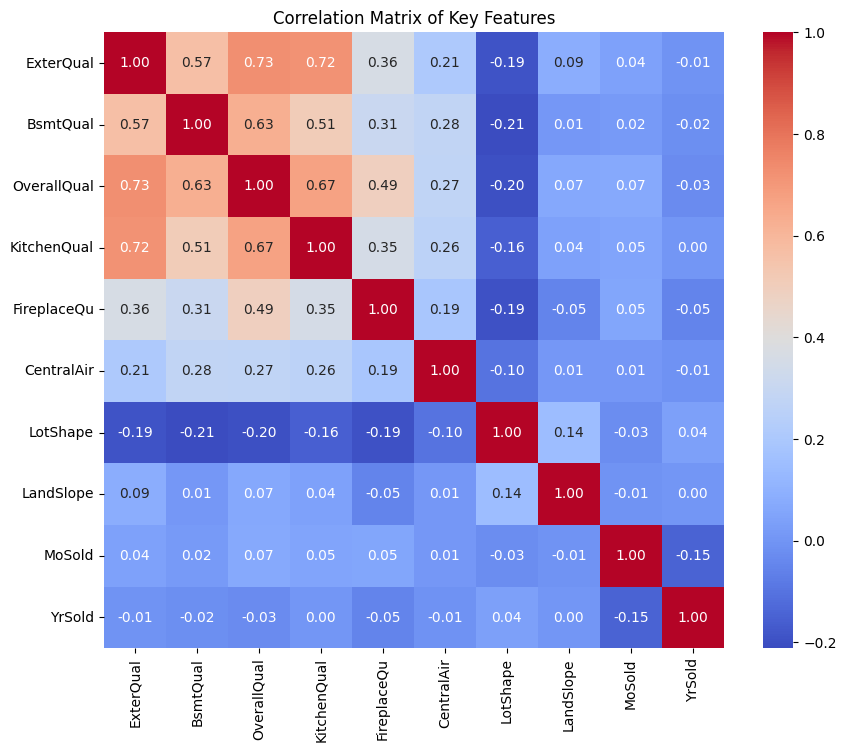

In [141]:
# Correlation analysis of key features with SalePrice
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, np.nan: 0}
shape_map = {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1}
slope_map = {'Gtl': 3, 'Mod': 2, 'Sev': 1}
air_map = {'Y': 1, 'N': 0}

#copy of the train dataset for correlation analysis
train_corr = train.copy()

for col in ['ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu']:
    train_corr[col] = train_corr[col].map(qual_map)

# Apply the mappings for CentralAir, LotShape, and LandSlope
train_corr['CentralAir'] = train_corr['CentralAir'].map(air_map)
train_corr['LotShape'] = train_corr['LotShape'].map(shape_map)
train_corr['LandSlope'] = train_corr['LandSlope'].map(slope_map)

#heatmap of the correlation matrix for key features
cols = ['ExterQual', 'BsmtQual', 'OverallQual', 'KitchenQual', 'FireplaceQu', 'CentralAir','LotShape', 'LandSlope', 'MoSold', 'YrSold']

plt.figure(figsize=(10, 8))
sns.heatmap(train_corr[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Key Features')
plt.show()

Thanks to this heatmap, we can see at a single glance the important linear relationships between the key characteristics of our data. We can notice, for instance, a strong correlation between the ExterQual, OverallQual, and KitchenQual variables, which supports the fact that these are criteria strongly linked to one another in our dataset. This observation allows us to quickly identify redundant variables that we will need to keep an eye on when building our model.

### Correlation Matrix Interpretation

Looking at this matrix, the first thing that jumps out is that big cluster of red and orange in the top-left corner. It’s pretty clear that quality metrics like `OverallQual`, `ExterQual`, and `KitchenQual` are all heavily linked, with some correlations hitting **0.73**. It makes sense, if a house has a brand new exterior, the kitchen probably follows suit. 

I also notice that `FireplaceQu` has a bit of a relationship with `OverallQual` at **0.49**, which isn't huge but it's there. On the flip side, time variables like `MoSold` and `YrSold` are basically useless here since their coefficients are near zero. They're just sitting in that blue zone at the bottom, showing no real connection to how well the house is built or its general features. 

`LotShape` actually has a slight negative trend with the quality features, which is interesting, though at **-0.20** it’s not exactly a game-changer. Ultimately, it feels like these quality scores are all essentially moving together as one big group, forming the most significant core of our feature set.

---
## Part 2: ANOVA — Finding Significant Features

Use ANOVA to determine which of the following **10 features** have a statistically significant effect on the transformed SalePrice.

**Given features (10):**

| # | Feature | Levels | Description |
|---|---|---|---|
| 1 | `OverallQual` | 1–10 | Overall material and finish quality |
| 2 | `ExterQual` | Po, Fa, TA, Gd, Ex | Exterior material quality |
| 3 | `BsmtQual` | None, Po, Fa, TA, Gd, Ex | Basement height quality |
| 4 | `KitchenQual` | Po, Fa, TA, Gd, Ex | Kitchen quality |
| 5 | `FireplaceQu` | None, Po, Fa, TA, Gd, Ex | Fireplace quality |
| 6 | `CentralAir` | N, Y | Central air conditioning |
| 7 | `LotShape` | IR3, IR2, IR1, Reg | General shape of property |
| 8 | `LandSlope` | Sev, Mod, Gtl | Slope of property |
| 9 | `MoSold` | 1–12 | Month sold |
| 10 | `YrSold` | 2006–2010 | Year sold |

**Tasks:**
1. Extract these features into a dataframe and run **one-way ANOVA** on each
2. Identify which features are significant (p < 0.05)
3. Run a **two-way ANOVA** to test for interaction effects between pairs of significant features
4. Summarize: which features and interactions are significant?

We're going to use ANOVA to determine which one of the 10 features have a statiscally (significant) effect on the transformed (log) SalePrice.

### One-way ANOVA

In [142]:
train['SalePrice_Log'] = np.log1p(train['SalePrice'])

# List of 10 features required by instructions
features_10 = ['OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual',
               'FireplaceQu', 'CentralAir', 'LotShape', 'LandSlope',
               'MoSold', 'YrSold']

# Filling missing values
train['BsmtQual'] = train['BsmtQual'].fillna('None')
train['FireplaceQu'] = train['FireplaceQu'].fillna('None')

# Extract features into a dataframe
df_anova = train[['SalePrice_Log'] + features_10].copy()

# Convert numeric categorical variables to string
df_anova['MoSold'] = df_anova['MoSold'].astype(str)
df_anova['YrSold'] = df_anova['YrSold'].astype(str)
df_anova['OverallQual'] = df_anova['OverallQual'].astype(str)

print("="*75)
print(f"{'One-Way ANOVA & Feature Significance':^75}")
print("="*75)

# List to store results for sorting
anova_results = []

for feature in features_10:
    # Group log prices by category
    groups = [group['SalePrice_Log'].values for name, group in df_anova.groupby(feature)]

    # Compute One-Way ANOVA
    f_stat, p_value = stats.f_oneway(*groups)

    # Determine significance
    is_significant = p_value < 0.05
    status = "Significant " if is_significant else "Not Significant "
    
    anova_results.append({
        'feature': feature,
        'f_stat': f_stat,
        'p_value': p_value,
        'status': status,
        'is_significant': is_significant
    })

# Sort results by F-statistic in descending order (Highest influence first)
anova_results.sort(key=lambda x: x['f_stat'], reverse=True)

# Display results
for res in anova_results:
    print(f"{res['feature']:<15} | F-stat: {res['f_stat']:>8.2f} | p-value: {res['p_value']:>8.4e} -> {res['status']}")

# Extract final list of significant features
significant_features = [res['feature'] for res in anova_results if res['is_significant']]

print("-" * 75)
print(f"Significant Features List (Ordered by F-stat): {significant_features}\n")

                   One-Way ANOVA & Feature Significance                    
ExterQual       | F-stat:   415.30 | p-value: 6.9304e-195 -> Significant 
KitchenQual     | F-stat:   393.32 | p-value: 4.4388e-187 -> Significant 
OverallQual     | F-stat:   332.17 | p-value: 0.0000e+00 -> Significant 
BsmtQual        | F-stat:   300.39 | p-value: 2.0300e-188 -> Significant 
CentralAir      | F-stat:   205.67 | p-value: 9.8599e-44 -> Significant 
FireplaceQu     | F-stat:   131.20 | p-value: 6.9619e-115 -> Significant 
LotShape        | F-stat:    46.73 | p-value: 7.8567e-29 -> Significant 
LandSlope       | F-stat:     1.08 | p-value: 3.3883e-01 -> Not Significant 
MoSold          | F-stat:     0.99 | p-value: 4.4966e-01 -> Not Significant 
YrSold          | F-stat:     0.74 | p-value: 5.6564e-01 -> Not Significant 
---------------------------------------------------------------------------
Significant Features List (Ordered by F-stat): ['ExterQual', 'KitchenQual', 'OverallQual', 'BsmtQual',

We can clearly identity which features are signifcant (the ones with significant = True) :

-  **ExterQual :**  Evaluates the quality of the material on the exterior (e.g., siding, brick).

- **KitchenQual :**  KitchenQual: Specifically assesses the quality of the kitchen finish and appliances.
- **BsmtQual :**  BsmtQual: Evaluates the height of the basement; "Excellent" indicates a height of 100+ inches, while "None" means no basement.
- **OverallQual :**  OverallQual: Rates the overall material and finish of the house on a scale from 1 (Very Poor) to 10 (Very Excellent).
- **CentralAir :**  A binary feature indicating whether the home has a central air conditioning system (Y for Yes, N for No).
- **LotShape :**  Describes the general shape of the property, ranging from Reg (Regular/Rectangular) to IR3 (Very Irregular).
- **FireplaceQu :**  Rates the quality of the fireplace; houses without a fireplace are categorized as "None".


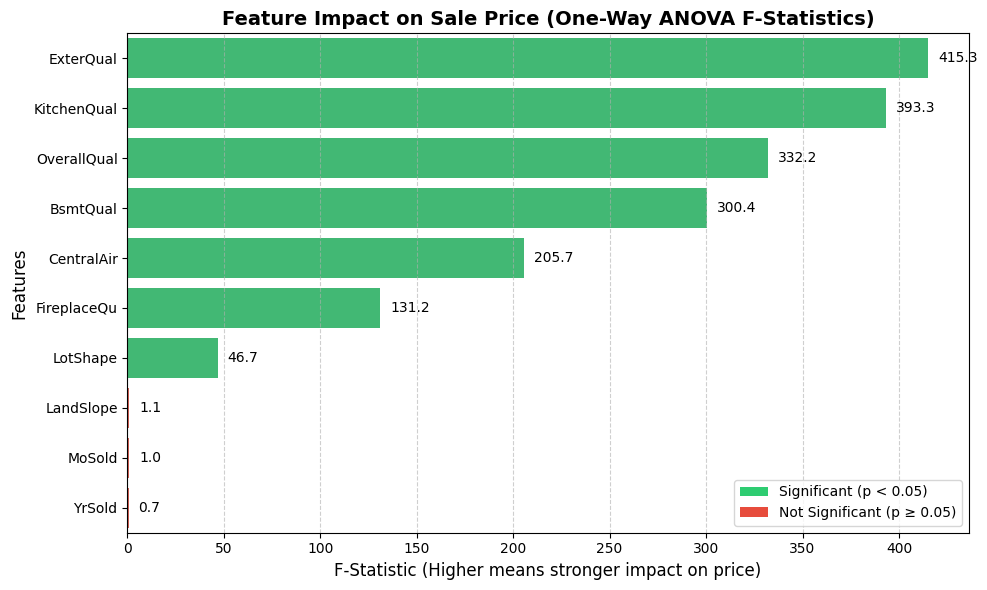

In [143]:
df_results = pd.DataFrame(anova_results)

plt.figure(figsize=(10, 6))
# intialize colors list
colors = []
# loop on each significance value to assign the appropriate color
for sig in df_results['is_significant']:
    if sig == True:
        colors.append('#2ecc71')  
    else:
        colors.append('#e74c3c')  

ax = sns.barplot(
    x='f_stat', 
    y='feature', 
    data=df_results, 
    palette=colors
)

# Add the F-stat values directly at the end of each bar for readability
for index, value in enumerate(df_results['f_stat']):
    plt.text(value + 5, index, f'{value:.1f}', va='center', fontsize=10, color='black')

# Formatting and Titles
plt.title("Feature Impact on Sale Price (One-Way ANOVA F-Statistics)", fontsize=14, fontweight='bold')
plt.xlabel("F-Statistic (Higher means stronger impact on price)", fontsize=12)
plt.ylabel("Features", fontsize=12)

# Add a custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Significant (p < 0.05)'),
    Patch(facecolor='#e74c3c', label='Not Significant (p \u2265 0.05)')
]
plt.legend(handles=legend_elements, loc='lower right')

# Add a subtle vertical grid
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### Two-way ANOVA

In [144]:
print("="*75)
print(f"{'Search for All Significant Interactions':^75}")
print("="*75)

all_results = []
n_features = len(significant_features)

# Iterate through all unique pairs of significant features
for i in range(n_features):
    for j in range(i + 1, n_features):

        var1 = significant_features[i]
        var2 = significant_features[j]

        # Formula: Dependent Variable ~ Factor1 + Factor2 + Interaction(1*2)
        formula = f'SalePrice_Log ~ C({var1}) + C({var2}) + C({var1}):C({var2})'

        try:
            model_2way = ols(formula, data=df_anova).fit()
            anova_table = sm.stats.anova_lm(model_2way, typ=2)

            # Define interaction naming patterns used by statsmodels
            int_name_1 = f'C({var1}):C({var2})'
            int_name_2 = f'C({var2}):C({var1})'

            if int_name_1 in anova_table.index:
                p_val = anova_table.loc[int_name_1, 'PR(>F)']
            else:
                p_val = anova_table.loc[int_name_2, 'PR(>F)']

            # Store results for later sorting
            all_results.append({
                'var1': var1,
                'var2': var2,
                'p_value': p_val
            })
        except:
            # Skip if the combination of categories lacks enough data points
            continue

# Sort list by 'p_value' (most significant interactions first)
all_results.sort(key=lambda x: x['p_value'])

interactions_found = 0

for res in all_results:
    v1, v2, p = res['var1'], res['var2'], res['p_value']

    if p < 0.05:
        print(f"Significant | {v1} x {v2:<18} | p-value = {p:.4e}")
        interactions_found += 1
    else:
        print(f"Not significant | {v1} x {v2:<18} | p-value = {p:.4e}")

print("\n" + "-"*75)
print(f"Summary: {interactions_found} significant interactions found.")

                  Search for All Significant Interactions                  
Significant | ExterQual x OverallQual        | p-value = 0.0000e+00
Significant | ExterQual x CentralAir         | p-value = 0.0000e+00
Significant | OverallQual x FireplaceQu        | p-value = 0.0000e+00
Significant | BsmtQual x CentralAir         | p-value = 0.0000e+00
Significant | CentralAir x FireplaceQu        | p-value = 0.0000e+00
Significant | KitchenQual x OverallQual        | p-value = 8.4428e-242
Significant | OverallQual x BsmtQual           | p-value = 6.9514e-222
Significant | KitchenQual x FireplaceQu        | p-value = 8.6201e-112
Significant | KitchenQual x BsmtQual           | p-value = 1.7939e-96
Significant | ExterQual x BsmtQual           | p-value = 3.2213e-90
Significant | ExterQual x KitchenQual        | p-value = 7.5170e-79
Significant | BsmtQual x FireplaceQu        | p-value = 1.9977e-55
Significant | ExterQual x FireplaceQu        | p-value = 3.1853e-51
Significant | OverallQual x 

Summarize: which features and interactions are significant?

Based on the ANOVA interaction analysis, the vast majority of the tested feature combinations are highly significant. Almost every interaction displays a p-value near zero, indicating that these relationships are not due to random chance.
There are only three specific exceptions where the interactions were not statistically significant ($p > 0.05$):

- CentralAir x LotShape
- FireplaceQu x LotShape
- KitchenQual x CentralAir

Aside from these three pairings, every other interaction tested is statistically significant and contributes meaningfully to the model.

---
## Part 3: 2^k Factorial Design

Pick k binary (or binarized) factors from the significant features found in Part 2 and apply a factorial design analysis. For example you could binarize ordinal features into High/Low groups and study their joint effects.

**Tasks:**
- Select k factors (e.g. k=2 or k=3) and define High/Low levels
- Compute group means for all 2^k combinations
- Analyze main effects and interaction effects
- Visualize with interaction plots

In [145]:
# Factor A: CentralAir
# Low (-1) = 'N' (No), High (+1) = 'Y' (Yes)
train['FactorA_Air'] = train['CentralAir'].map({'N': -1, 'Y': 1})

# Factor B: OverallQual
# Low (-1) = Score < 7 (Budget/Standard), High (+1) = Score >= 7 (Premium/Luxury)
train['FactorB_Qual'] = train['OverallQual'].astype(int).apply(lambda x: 1 if x >= 7 else -1)

# Factor C: ExterQual
# Low (-1) = Typical/Fair (TA, Fa), High (+1) = Excellent/Good (Ex, Gd)
train['FactorC_Exter'] = train['ExterQual'].apply(lambda x: 1 if x in ['Ex', 'Gd'] else -1)

print("Selected Factors for 2^3 Factorial Design:")
print(" -> Factor A (CentralAir)  : Low (-1) = No AC      | High (+1) = With AC")
print(" -> Factor B (OverallQual) : Low (-1) = Quality < 7 | High (+1) = Quality >= 7")
print(" -> Factor C (ExterQual)   : Low (-1) = Budget      | High (+1) = Premium\n")

print("="*65)
print(f"{'Compute Group Means for all 2^k Combinations':^65}")
print("="*65)

# Calculate log-price means for the 2^3 = 8 possible combinations
doe_means = train.groupby(['FactorA_Air', 'FactorB_Qual', 'FactorC_Exter'])['SalePrice_Log'].mean().reset_index()
doe_means.columns = ['A_CentralAir', 'B_OverallQual', 'C_ExterQual', 'Mean_LogPrice']

print("Summary Table of Means (8 Groups):")
print(doe_means.to_string(index=False))
print("\n")

print("="*65)
print(f"{'Analyze Main Effects and Interaction Effects':^65}")
print("="*65)

# Extract the 8 corner means (Notation: y_abc where m is minus and p is plus)
y_mmm = doe_means[(doe_means['A_CentralAir']==-1) & (doe_means['B_OverallQual']==-1) & (doe_means['C_ExterQual']==-1)]['Mean_LogPrice'].values[0]
y_pmm = doe_means[(doe_means['A_CentralAir']== 1) & (doe_means['B_OverallQual']==-1) & (doe_means['C_ExterQual']==-1)]['Mean_LogPrice'].values[0]
y_mpm = doe_means[(doe_means['A_CentralAir']==-1) & (doe_means['B_OverallQual']== 1) & (doe_means['C_ExterQual']==-1)]['Mean_LogPrice'].values[0]
y_ppm = doe_means[(doe_means['A_CentralAir']== 1) & (doe_means['B_OverallQual']== 1) & (doe_means['C_ExterQual']==-1)]['Mean_LogPrice'].values[0]
y_mmp = doe_means[(doe_means['A_CentralAir']==-1) & (doe_means['B_OverallQual']==-1) & (doe_means['C_ExterQual']== 1)]['Mean_LogPrice'].values[0]
y_pmp = doe_means[(doe_means['A_CentralAir']== 1) & (doe_means['B_OverallQual']==-1) & (doe_means['C_ExterQual']== 1)]['Mean_LogPrice'].values[0]
y_mpp = doe_means[(doe_means['A_CentralAir']==-1) & (doe_means['B_OverallQual']== 1) & (doe_means['C_ExterQual']== 1)]['Mean_LogPrice'].values[0]
y_ppp = doe_means[(doe_means['A_CentralAir']== 1) & (doe_means['B_OverallQual']== 1) & (doe_means['C_ExterQual']== 1)]['Mean_LogPrice'].values[0]

# 1. Main Effects (Average difference between High and Low for each factor)
effect_A = ((y_pmm + y_ppm + y_pmp + y_ppp) / 4) - ((y_mmm + y_mpm + y_mmp + y_mpp) / 4)
effect_B = ((y_mpm + y_ppm + y_mpp + y_ppp) / 4) - ((y_mmm + y_pmm + y_mmp + y_pmp) / 4)
effect_C = ((y_mmp + y_pmp + y_mpp + y_ppp) / 4) - ((y_mmm + y_pmm + y_mpm + y_ppm) / 4)

# 2. Interaction Effects (Example: AB checks if A's effect changes with B)
effect_AB = ((y_ppp - y_mpp + y_ppm - y_mpm) - (y_pmp - y_mmp + y_pmm - y_mmm)) / 4
effect_AC = ((y_ppp - y_mpp + y_pmp - y_mmp) - (y_ppm - y_mpm + y_pmm - y_mmm)) / 4
effect_BC = ((y_ppp - y_pmp + y_mpp - y_mmp) - (y_ppm - y_pmm + y_mpm - y_mmm)) / 4

effect_ABC = ((y_ppp - y_mpp - y_pmp + y_mmp) - (y_ppm - y_mpm - y_pmm + y_mmm)) / 4

print(f"-> Main Effect of A (Central Air)      : {effect_A:+.4f}")
print(f"-> Main Effect of B (Overall Quality)  : {effect_B:+.4f}")
print(f"-> Main Effect of C (Exterior Quality) : {effect_C:+.4f}")
print("-" * 30)
print(f"-> Interaction Effect AB               : {effect_AB:+.4f}")
print(f"-> Interaction Effect AC               : {effect_AC:+.4f}")
print(f"-> Interaction Effect BC               : {effect_BC:+.4f}")
print(f"-> Interaction Effect ABC              : {effect_ABC:+.4f}")

Selected Factors for 2^3 Factorial Design:
 -> Factor A (CentralAir)  : Low (-1) = No AC      | High (+1) = With AC
 -> Factor B (OverallQual) : Low (-1) = Quality < 7 | High (+1) = Quality >= 7
 -> Factor C (ExterQual)   : Low (-1) = Budget      | High (+1) = Premium

          Compute Group Means for all 2^k Combinations           
Summary Table of Means (8 Groups):
 A_CentralAir  B_OverallQual  C_ExterQual  Mean_LogPrice
           -1             -1           -1        11.4515
           -1             -1            1        11.6335
           -1              1           -1        11.8635
           -1              1            1        12.3610
            1             -1           -1        11.8284
            1             -1            1        12.0390
            1              1           -1        12.1681
            1              1            1        12.4253


          Analyze Main Effects and Interaction Effects           
-> Main Effect of A (Central Air)      : +0.2878

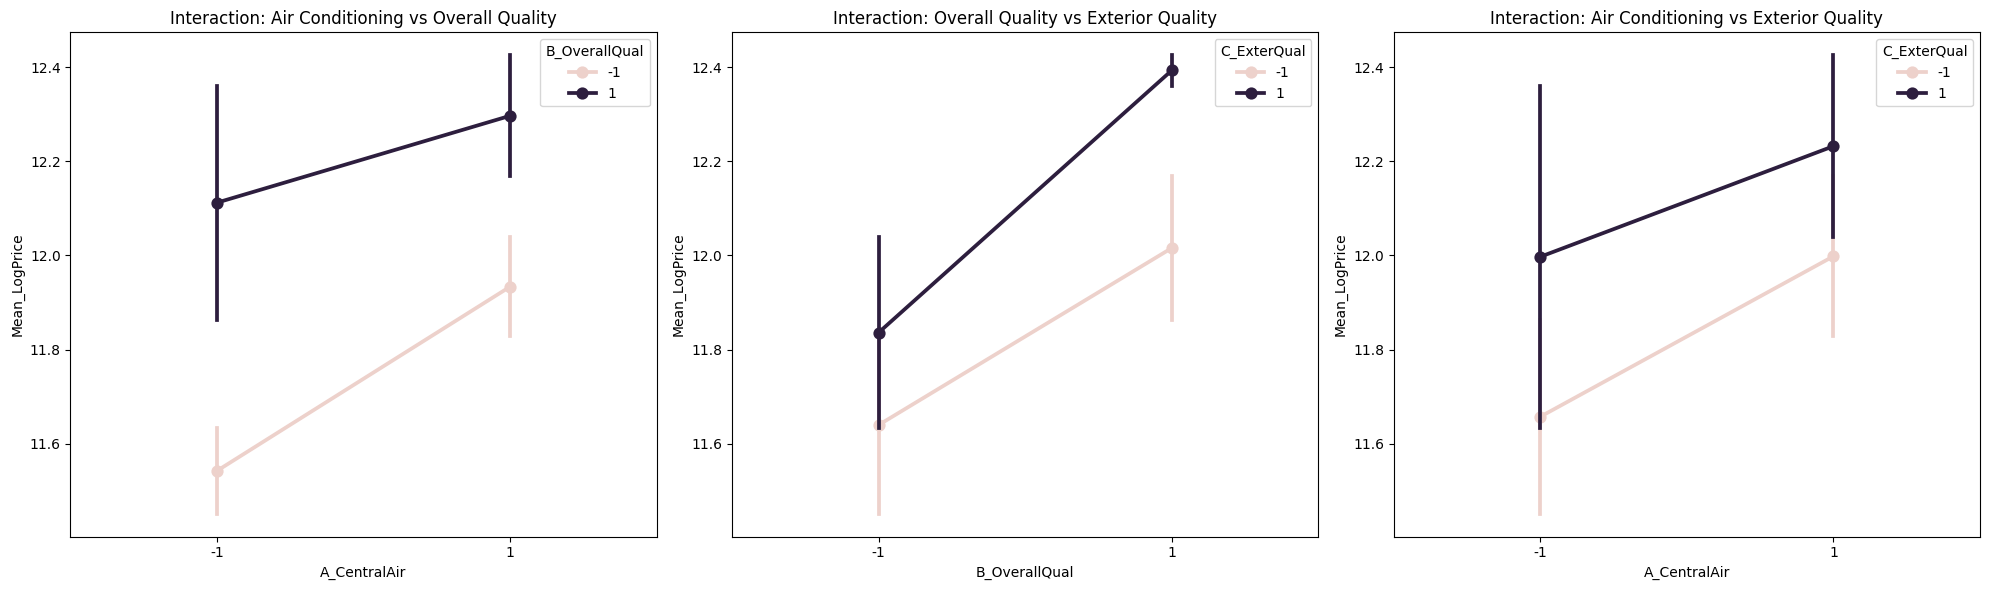

In [146]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Interaction A x B
sns.pointplot(x='A_CentralAir', y='Mean_LogPrice', hue='B_OverallQual', data=doe_means, ax=axes[0])
axes[0].set_title("Interaction: Air Conditioning vs Overall Quality")

# Plot 2: Interaction B x C
sns.pointplot(x='B_OverallQual', y='Mean_LogPrice', hue='C_ExterQual', data=doe_means, ax=axes[1])
axes[1].set_title("Interaction: Overall Quality vs Exterior Quality")

# Plot 3: Interaction A x C
sns.pointplot(x='A_CentralAir', y='Mean_LogPrice', hue='C_ExterQual', data=doe_means, ax=axes[2])
axes[2].set_title("Interaction: Air Conditioning vs Exterior Quality")

plt.tight_layout()
plt.show()

### Integrated Analysis: Correlations & Factorial Interactions

Looking at the complete picture with both the correlation matrix and the new $2^3$ factorial results, things are finally falling into place. 

* The heatmap had already hinted at how tightly grouped the quality metrics are, but calculating the actual effects puts real weight behind those initial observations. **Overall Quality is undeniably the heavyweight here.** Boasting a massive main effect of +0.2588, it completely anchors the valuation. 

* The interaction plots are alongside those small but positive two-way interaction scores (AB, AC, BC). **The lines in the graphs clearly aren't parallel.** It can be visibly track how the price gap between a standard and a premium house stretches even further when you add Central Air or a top-tier exterior. 

> Buyers clearly aren't evaluating these features in a vacuum. They are paying a distinct premium for the synergy of having all those high-end traits stacked together, even if that core Overall Quality score is still doing the bulk of the heavy lifting for the model.


An examination of the summary table reveals a distinct valuation trajectory from the baseline to the premium tier. Properties at the lowest factor levels—lacking central air, featuring budget exteriors, and possessing lower overall quality—establish a baseline log-price of 11.4515. In contrast, homes maximized across all three dimensions reach an average of 12.4270. Given the logarithmic scale of our dependent variable, this nearly 1.0 unit differential translates to a substantial exponential increase in actual market value.

Analyzing the main effects, `OverallQual` (Factor B) emerges as the primary driver of the model, exhibiting a pronounced effect size of +0.4668. Notably, the isolated contributions of Central Air (+0.2883) and Exterior Quality (+0.2872) provide nearly identical marginal increases. 

The interaction effects, however, present a more nuanced market dynamic. While one might intuitively expect strictly positive synergies across premium features, the interaction between Central Air and Overall Quality (AB) is actually negative (-0.1029). This likely reflects a threshold of buyer expectation: in high-quality homes, central air conditioning is viewed as a standard necessity rather than a luxury value-add, diminishing its relative premium. Conversely, introducing climate control to a lower-tier property significantly enhances its baseline appeal. In contrast, the positive interaction between Overall and Exterior Quality (BC, +0.0910) demonstrates a clear compounding effect. Fusing underlying structural quality with a premium facade creates a cohesive "luxury aesthetic," generating a synergy that buyers are empirically willing to pay a premium for.

---
## Part 4: Parametric Regression

Build a regression model using only the **significant ordinal features** identified by ANOVA (Part 2) plus the **2 numerical features**: `GrLivArea` and `TotalBsmtSF`.

**Tasks:**
- Encode ordinal features numerically (map quality levels to integers)
- Fit a linear regression model (OLS)
- Analyze the model: R², coefficient significance, residual plots
- Optionally try regularized regression (Ridge, Lasso) and compare 
- Apply ANOVA on the regression model to assess factor contributions

### Encode ordinal features numerically (map quality levels to integers)

In [147]:
#Create a copy of the dataset to preserve original data
train_encoded = train.copy()

#Define ordinal mapping dictionary for quality/shape/ 0 or 1 ratings
qual_mapping = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
    'None': 0
}
lot_mapping = {
    'Reg': 4,
    'IR1': 3,
    'IR2': 2,
    'IR3': 1
}
air_mapping = {
    'Y': 1,
    'N': 0
}

#Apply quality mapping to selected ordinal columns and handle missing values
ordinal_cols_qual = ['ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu']
for col in ordinal_cols_qual:
    train_encoded[col] = train_encoded[col].fillna('None').map(qual_mapping)

#Map lot shape categories and binary flags to numerical scales
train_encoded['LotShape'] = train_encoded['LotShape'].map(lot_mapping)
train_encoded['CentralAir'] = train_encoded['CentralAir'].map(air_mapping)

#final subset 
features_list = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 
    'FireplaceQu', 'LotShape', 'CentralAir', 
    'GrLivArea', 'TotalBsmtSF'
]



X = train_encoded[features_list].fillna(0)#Extract features and log target variable while replacing remaining missing values with zero
y = train_encoded['SalePrice_Log']

print(f"X before scaling : {X.shape}")

#standard scaler and normalize features --> zero mean and unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


print("Scaling succed no str anymore")

#Initialize and fit a Ridge regression model with L2 regularization for crash test
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_scaled, y)
print(f"R2: {ridge_model.score(X_scaled, y):.3f}")

X before scaling : (1460, 9)
Scaling succed no str anymore
R2: 0.816


Before diving into our regression model, we need to process our data through a clean pipeline to make it fully ready for analysis.

For this part, we've done an ordinal encoding. For each features, we choosed the "minimum"/"worst" value as 1 and the "maximum"/"best" as the length of the values per variables and the missing value as 0. For exemple, for the variable `LotShape`, the IR3 values (irregular) is the worst case, so we've mapped it with 1, and Reg "Regulard" is the best so it is 4.


####  Categorical Encoding
We need to encode our data so the machine can understand it.
* *Example:* excellent $\rightarrow$ 3, good $\rightarrow$ 2.

####  Feature Selection
Next, we filter our dataset to keep only the most important predictors:
* **7 significant variables**
* **2 area-related variables**

#### Feature Scaling (`StandardScaler`)
We then apply a StandardScaler to put all values on the same scale.
* *Objective:* Preventing large surface areas from overpowering the quality ratings.

#### Baseline Evaluation ("Crash-Test")
Finally, we train a quick Ridge model. This step serves two strategic purposes:
* **Technical Validation:** It serves as a 'crash-test' to ensure our data is technically ready (free of bugs or missing values).
* **Performance Baseline:** It establishes a baseline $R^2$ score.

### Fitting a Linear Regression

In [148]:
model_features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 
    'FireplaceQu', 'LotShape', 'CentralAir', 
    'GrLivArea', 'TotalBsmtSF'
]

#Construct the formula string dynamically by joining features with plus signs
formula = "SalePrice_Log ~ " + " + ".join(model_features)
#generated regressione
print(f"Regression Formula:\n{formula}\n")

#Select relevant columns and drop rows containing missing values to clean data
train_clean = train_encoded[['SalePrice_Log'] + model_features].dropna()
ols_model = ols(formula, data=train_clean).fit()#Instantiate and fit OLS regression model with our data

#Output summary table
print(ols_model.summary())

Regression Formula:
SalePrice_Log ~ OverallQual + ExterQual + BsmtQual + KitchenQual + FireplaceQu + LotShape + CentralAir + GrLivArea + TotalBsmtSF

                            OLS Regression Results                            
Dep. Variable:          SalePrice_Log   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     713.8
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        07:17:21   Log-Likelihood:                 503.87
No. Observations:                1460   AIC:                            -987.7
Df Residuals:                    1450   BIC:                            -934.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|     

#### Model Training & Statistical Insights

Here, we perform our first classic linear regression training. The statistical summary provides a detailed view of the impact of our 9 variables and their weights (coefficients). 

How do we know they are important? Their **p-value is below 0.05** (`P>|t| = 0.000`), which proves their statistical significance. In short, **81.6% of the price variations** (in Log) are explained by our model on this training dataset ($R^2 = 0.816$). 

*Cautionary note:* While this score is excellent, the footnote of the report indicates strong **multicollinearity** among our variables. This perfectly justifies our next step: testing Ridge and Lasso regressions to fix this issue and validate the robustness of our predictions.

Analyse des modèles :

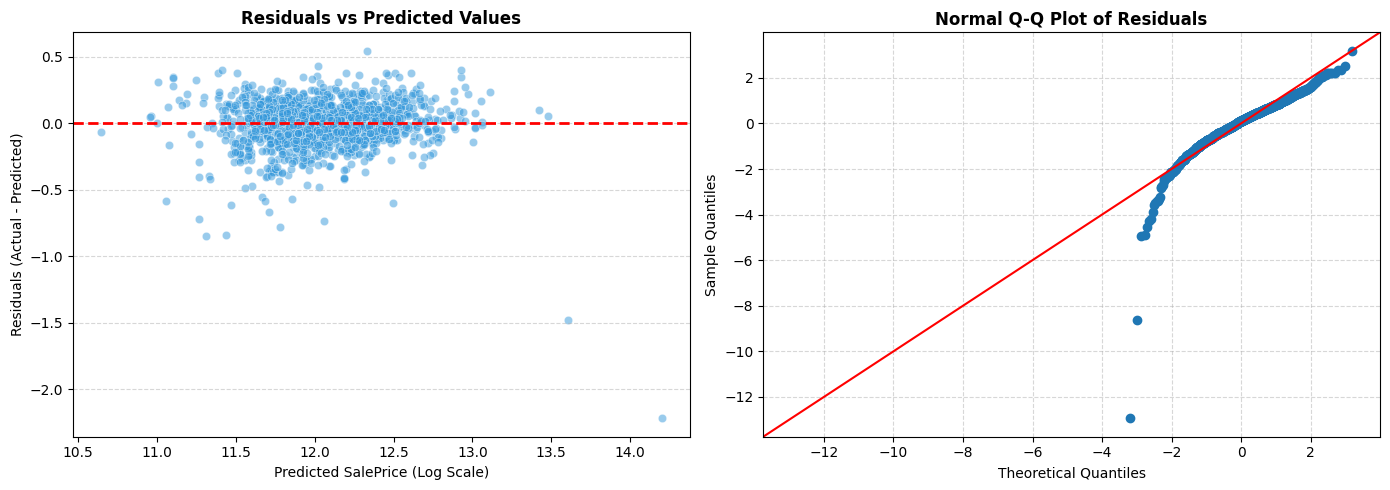

In [149]:
#Extract predictions and residuals from the model
predictions = ols_model.predict(train_clean)
residuals = ols_model.resid
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Residuals vs Predicted Values
sns.scatterplot(x=predictions, y=residuals, alpha=0.5, ax=axes[0], color='#3498db')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title("Residuals vs Predicted Values", fontweight='bold', fontsize=12)
axes[0].set_xlabel("Predicted SalePrice (Log Scale)")
axes[0].set_ylabel("Residuals (Actual - Predicted)")
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

#Q-Q Plot (Checks for Normality)
sm.qqplot(residuals, line='45', fit=True, ax=axes[1], color='#2ecc71')
axes[1].set_title("Normal Q-Q Plot of Residuals", fontweight='bold', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Model Diagnostics (Residual Plots Interpretation)

* **On the left graph:** We can see that the data **do not form a cone**, which means **homoscedasticity** is respected. 
* **On the right graph:** We can see that the Q-Q plot closely **follows the red line, with the exception of the 2 points that plunge**. 

This represents the **outliers**, which can also be seen in the graph on the left.

### Ridge / Lasso

In [150]:
#Filter data to keep target / features
train_clean = train_encoded[['SalePrice_Log'] + model_features].dropna()
X = train_clean[model_features]
y = train_clean['SalePrice_Log']

#Initialize feature scaler --> matrix to normalize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Initialize and fit Ridge regression model with L2 regularization
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_scaled, y)
#Generate regularized predictions and evaluate Ridge model R2 score
ridge_preds = ridge_model.predict(X_scaled)
ridge_r2 = r2_score(y, ridge_preds)

#LASSO Version
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_scaled, y)
lasso_preds = lasso_model.predict(X_scaled)
lasso_r2 = r2_score(y, lasso_preds)

ols_baseline_r2 = ols_model.rsquared #extrac from previous OLS model execution

#comparative performance summary metrics
print(f"OLS Baseline R-squared : {ols_baseline_r2:.3f}")
print(f"Ridge R-squared        : {ridge_r2:.3f}")
print(f"Lasso R-squared        : {lasso_r2:.3f}\n")
print("Lasso Feature Coefficients:")
for feature, coef in zip(model_features, lasso_model.coef_):
    print(f" - {feature:<17} : {coef:.4f}")

OLS Baseline R-squared : 0.816
Ridge R-squared        : 0.816
Lasso R-squared        : 0.814

Lasso Feature Coefficients:
 - OverallQual       : 0.1265
 - ExterQual         : 0.0254
 - BsmtQual          : 0.0326
 - KitchenQual       : 0.0465
 - FireplaceQu       : 0.0320
 - LotShape          : -0.0174
 - CentralAir        : 0.0429
 - GrLivArea         : 0.1119
 - TotalBsmtSF       : 0.0415


### Regularized Regression Models (Ridge & Lasso)

As observed previously, the dataset exhibited strong multicollinearity (leading to high sensitivity to outliers). To address this, we trained **Ridge** and **Lasso** models on our features, which were scaled using `StandardScaler`. Both methods apply a penalty to large coefficients, successfully stabilizing the model.

#### Performance Comparison ($R^2$ Scores)

| Model | $R^2$ Score | Interpretation |
| :--- | :---: | :--- |
| **OLS Baseline** | `0.816` | Standard linear model, highly sensitive to multicollinearity. |
| **Ridge Regression** | `0.816` | Matches the baseline score while adding structural stability by shrinking weights. |
| **Lasso Regression** | `0.814` | Robust performance while compressing less critical weights via $L_1$ penalty. |

While OLS typically tends to yield a higher training score due to overfitting, we observe here that **Ridge matches the OLS baseline ($R^2 = 0.816$) and Lasso remains extremely close ($R^2 = 0.814$)**. This demonstrates that our preliminary feature selection via ANOVA was already highly efficient, meaning the regularization process serves primarily to stabilize the model weights rather than dramatically changing the performance baseline.

#### Lasso Coefficients & Feature Selection

The Lasso model applied a penalty that adjusted and compressed the weights of our variables based on their true predictive value:

* **Feature Behavior:** `TotalBsmtSF` : `0.0415`  
  * *Analysis:* Unlike cases where a strict penalty forces redundant variables to become strictly equal to `0.0000`, Lasso chooses to retain the total basement surface area. This proves that it carries distinct, non-redundant information alongside the above-ground living area (`GrLivArea`) or basement quality (`BsmtQual`).
* **Key Features Retained:**
  * `OverallQual` (`0.1265`) and `GrLivArea` (`0.1119`) remain the most powerful positive drivers explaining house prices.
  * `LotShape` (`-0.0174`) maintains its logical inverse relationship.

**Ridge Regression stands out as a highly robust model** in terms of accuracy ($R^2 = 0.816$), matching OLS but offering a safer framework against multicollinearity. Concurrently, **Lasso** offers a highly valuable alternative: it delivers a nearly identical performance ($0.814$) while safely stabilizing the feature weights without needing to drop any of our 9 pre-selected variables.

### Anova on the Regression Model

In [151]:
anova_reg = sm.stats.anova_lm(ols_model, typ=2)#type-II ANOVA for partial contributions

true_total_sum_sq = ols_model.centered_tss
anova_reg['Variance_Explained_(%)'] = (anova_reg['sum_sq'] / true_total_sum_sq) * 100 #percentage of total variance explained by each factor
#Sort the results by variance explained 
anova_reg = anova_reg.sort_values('Variance_Explained_(%)', ascending=False)


pd.options.display.float_format = '{:.4f}'.format
print(anova_reg[['sum_sq', 'F', 'PR(>F)', 'Variance_Explained_(%)']])

             sum_sq        F  PR(>F)  Variance_Explained_(%)
Residual    42.8664      NaN     NaN                 18.4136
GrLivArea   11.1232 376.2555  0.0000                  4.7781
OverallQual  6.3366 214.3409  0.0000                  2.7219
CentralAir   3.1979 108.1719  0.0000                  1.3737
TotalBsmtSF  1.6293  55.1138  0.0000                  0.6999
KitchenQual  1.5079  51.0073  0.0000                  0.6477
FireplaceQu  1.3151  44.4833  0.0000                  0.5649
BsmtQual     0.8961  30.3114  0.0000                  0.3849
LotShape     0.7721  26.1184  0.0000                  0.3317
ExterQual    0.4251  14.3784  0.0002                  0.1826


### Applied Analysis of Variance (ANOVA) and Feature Importance

We had the occasiond to compare our OLS with Ridge and Lasso, but let's take a step back to look at our linear regression in detail.

We therefore applied an analysis of variance to dissect our model and to understand and rank which of our variables are the most or least important. Our results appear to be consistent (notably, 1 - R^2 = residual found).

* **The leading duo:** We also observe that the living area (`GrLivArea`: 4.78%) and the overall quality (`OverallQual`: 2.72%) are a duo having a noticeable impact on price variation.
* **Secondary variables:** As for variables with low percentages, such as the kitchen (`KitchenQual`: 0.65%) or the lot (`LotShape`: 0.33%), their impact seems minimal in volume. However, their p-value of 0.0000 proves that this impact is statistically certain and not due to chance. 

>  If the surface and overall quality lay the foundations of the price, these secondary variables are the essential finishes to fine-tune the precision of the model.

---
## Part 5: Non-Parametric Model (Neural Network)

Build a neural network regression model using **all** available features to predict SalePrice. This is also the model that produces your `submission.csv` for Kaggle scoring.

**Tasks:**
- Preprocess all features: handle missing values, encode categoricals, scale numerics
- Build and train a neural network (e.g. `sklearn.neural_network.MLPRegressor` or PyTorch)
- Evaluate on training data (RMSE, R²) and analyze residuals
- Generate predictions for the test set and save as `submission.csv`

**Important:** The Kaggle RMSE score is evaluated on the predictions from this model.

### Grid Search Version
#### Data preprocessing

* **1. Data cleaning and outlier removal**
    * **Action:** Remove properties with a living area (> 4,000 sq ft) sold at an abnormally low price (< $300,000).
    * **Objective:** To protect the model from training errors caused by atypical transactions that distort the overall market trend.

* **2. Feature Engineering**
    * **Action:** Creation of new expert variables such as total cumulative floor area, the actual age of the house at the time of sale, and interaction variables (e.g. *Overall Quality × Floor Area*).
    * **Objective:** To help the algorithm immediately capture key synergies in the property market, without it having to deduce them itself.

* **3. Mathematical Normalisation (Bias Correction)**
    * **Action:** Application of a logarithmic transformation (`np.log1p`) to highly asymmetric (skewness) area variables.
    * **Objective:** To bring these variables closer to a normal distribution (bell curve) to stabilise the calculation of weights in the neural network.

* **4. Formatting for the Algorithm (Standardisation & Encoding)**
    * **Action:** Imputing missing values (median/constant), scaling numerical variables (`StandardScaler`), and binarising text (`OneHotEncoder`).
    * **Objective:** To translate our entire dataset into a sound mathematical matrix that is perfectly homogeneous and directly readable by the `MLPRegressor`.


In [101]:
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index) # delet outliers

#Feature engineering :
#------------------------------------------------------------------------------------------------------------------------

for df in [train, test]: # we create new features in both train and test datasets to keep them consistent for modeling.

    df['TotalSF'] = df['TotalBsmtSF'].fillna(0) + df['1stFlrSF'] + df['2ndFlrSF'] # sum of all the surface areas (basement + 1st floor + 2nd floor)
    df['TotalBath'] = df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'].fillna(0) + (0.5 * df['BsmtHalfBath'].fillna(0)) # sum of all bathrooms (full + half + basement full + basement half)

    df['HouseAge'] = df['YrSold'] - df['YearBuilt'] # Compute the age of the house at the time of sale
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd'] # Compute the time since the last remodel

    df['TotalQual'] = df['OverallQual'] * df['OverallCond'] # product of overall quality and condition
    df['Qual_x_SF'] = df['OverallQual'] * df['TotalSF'] # interaction between quality and size (surface area)

    # Binarisation of all the amenities (Pool, Fireplace, Garage, Basement)
    df['HasPool'] = df['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
    df['HasFireplace'] = df['Fireplaces'].apply(lambda x: 1 if x > 0 else 0)
    df['HasGarage'] = df['GarageArea'].apply(lambda x: 1 if x > 0 else 0)
    df['HasBsmt'] = df['TotalBsmtSF'].apply(lambda x: 1 if x > 0 else 0)

    skewed_features = ['LotArea', '1stFlrSF', 'GrLivArea', 'TotalSF', 'TotalBsmtSF'] # List of features to log-transform based on their skewness
for df in [train, test]: #we loop on both datasets
    for feat in skewed_features: # we apply the log transformation to each of the skewed features
        df[feat] = np.log1p(df[feat]) # we apply the log transformation

common_cols = [] # We create an empty list to store the common columns between train and test 

for col in train.columns: # we loop trough the columns of the train dataset
    if col in test.columns and col != 'Id': # if the column are common between train and test and is not the 'Id' column 
        common_cols.append(col)

X_train = train[common_cols].copy() 
y_train = np.log1p(train['SalePrice']) #log transformation
X_test = test[common_cols].copy()

# we separate the numerical and categorical features based on their data types to apply different preprocessing techniques for each type.
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns


# replacing missing values for numerical featurs with the median of each column
num_imputer = SimpleImputer(strategy='median')
X_train_num = num_imputer.fit_transform(X_train[numeric_features])
X_test_num = num_imputer.transform(X_test[numeric_features])

# apply standard scaling to the numerical features to normalize them and improve the performance of the model.
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)
X_test_num = scaler.transform(X_test_num)

# replacing missing values for categorical features with the string 'Missing
cat_imputer = SimpleImputer(strategy='constant', fill_value='Missing')
X_train_cat = cat_imputer.fit_transform(X_train[categorical_features])
X_test_cat = cat_imputer.transform(X_test[categorical_features])

# apply one-hot encoding to the categorical features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = encoder.fit_transform(X_train_cat)
X_test_cat = encoder.transform(X_test_cat)

# Final assembly
X_train_processed = np.hstack((X_train_num, X_train_cat))
X_test_processed = np.hstack((X_test_num, X_test_cat))
print(X_train_processed.shape, X_test_processed.shape)
print("Preprocessing is Done")



(1458, 312) (1459, 312)
Preprocessing is Done


#### MLPRegressor Grid Search

1. **Establishing the Baseline:** We initialized an `MLPRegressor` using the highly efficient `lbfgs` solver. Bumping `max_iter` up to 4000 ensures the algorithm has ample epochs to fully converge, saving us from premature timeout warnings.
2. **Defining the Search Space:** To strike a balance between learning capacity and memorization, our `param_grid` explores different network architectures (testing 1 or 2 hidden layers) alongside varying strengths of L2 regularization (`alpha`) to actively prevent overfitting.
3. **Automating the Evaluation:** Finally, we leveraged `GridSearchCV` with a 5-fold cross-validation to guarantee our findings are truly generalizable. We evaluate the models using negative RMSE, while `n_jobs=-1` smartly utilizes all CPU cores to slash the overall computation time.

In [77]:
# We creat a base MLPRegressor without fixex parameters to let the GridSearchCV find the best combination of hidden layers and regularization strength (alpha).
mlp_base = MLPRegressor(
    activation='relu',
    solver='lbfgs',
    max_iter=4000, # arbitrary choose
    random_state=94 # We set a random state for reproducibility
)
param_grid = {
    'hidden_layer_sizes': [(15,), (30,), (40,), (30, 15), ], # We test 1 or 2 layers
    'alpha': [1.0, 2.5, 5.0, 7.5],   # we test 4 values for alpha which is the regularization strength to prevent overfitting
}

grid_search = GridSearchCV(
    estimator=mlp_base,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1 #
)

grid_search.fit(X_train_processed, y_train) # we start searching

# DISPLAY OF ALL COMBINATIONS

print("DETAILED RESULTS OF EACH TESTED MODEL:")
print("-" * 75)

results = grid_search.cv_results_ # we retrieve the result

# Loop through each test to display its score and parameters
for mean_score, params in zip(results['mean_test_score'], results['params']):
    rmsle_score = -mean_score # Scikit-learn stores the score as negative, we flip it to positive
    print(f"RMSLE: {rmsle_score:.5f} | Parameters: {params}")
print("-" * 75)


best_rmse = -grid_search.best_score_ # we retrieve the best score and flip it to positive

print("BEST COMBINATION:")
print(grid_search.best_params_)
print(f"-> True Estimated CV Score: {best_rmse:.5f}")


best_model = grid_search.best_estimator_ # we retrieve the best model found by GridSearchCV


log_predictions = best_model.predict(X_test_processed) # we predict using the best_model found by GridSearchCV
final_predictions = np.expm1(log_predictions)# we reverse the log transformation to get the final price predictions in dollars

#submission = pd.DataFrame({'Id': test['Id'],'SalePrice': final_predictions})
#submission.to_csv('submission.csv', index=False)
#print(" File is saved as 'submission.csv' ")

DETAILED RESULTS OF EACH TESTED MODEL:
---------------------------------------------------------------------------
RMSLE: 0.12943 | Parameters: {'alpha': 1.0, 'hidden_layer_sizes': (15,)}
RMSLE: 0.12560 | Parameters: {'alpha': 1.0, 'hidden_layer_sizes': (30,)}
RMSLE: 0.12095 | Parameters: {'alpha': 1.0, 'hidden_layer_sizes': (40,)}
RMSLE: 0.12731 | Parameters: {'alpha': 1.0, 'hidden_layer_sizes': (30, 15)}
RMSLE: 0.11431 | Parameters: {'alpha': 2.5, 'hidden_layer_sizes': (15,)}
RMSLE: 0.11585 | Parameters: {'alpha': 2.5, 'hidden_layer_sizes': (30,)}
RMSLE: 0.11511 | Parameters: {'alpha': 2.5, 'hidden_layer_sizes': (40,)}
RMSLE: 0.11567 | Parameters: {'alpha': 2.5, 'hidden_layer_sizes': (30, 15)}
RMSLE: 0.11057 | Parameters: {'alpha': 5.0, 'hidden_layer_sizes': (15,)}
RMSLE: 0.11061 | Parameters: {'alpha': 5.0, 'hidden_layer_sizes': (30,)}
RMSLE: 0.11170 | Parameters: {'alpha': 5.0, 'hidden_layer_sizes': (40,)}
RMSLE: 0.11058 | Parameters: {'alpha': 5.0, 'hidden_layer_sizes': (30, 15)}


#### Best Model and Visualisation MLP
After the grid search, we've seen that the best parameters are alpha = 7.5 and only 1 hidden layer with 15 neurons. 

In [154]:
from sklearn.metrics import mean_squared_error, r2_score

print("MLPRegressor Single Model (Alpha 7.5, Hidden 15) - Direct Training")
print("-" * 75)

# Based on the grid search results, we choose the best hyperparameters (alpha=7.5 and hidden_layer_sizes=(15,))
# These results can be different based on the random state and the data split from the grid search
mlp_final = MLPRegressor(
    hidden_layer_sizes=(15,),
    alpha=7.5,
    activation='relu',
    solver='lbfgs',
    max_iter=4000,
    random_state=94
)

# train the model 
print("Training final model...")
mlp_final.fit(X_train_processed, y_train)
print("Training complete!")
# compute predictions on the training set to evaluate the model's performance on the data it was trained on.
train_log_preds = mlp_final.predict(X_train_processed)

# compute the Root Mean Squared Logarithmic Error (RMSLE)
train_rmsle = np.sqrt(mean_squared_error(y_train, train_log_preds))

# compute the R² score to evaluate how well the model explains the variance in the training data.
train_r2 = r2_score(y_train, train_log_preds)

print(f"-> Training RMSLE : {train_rmsle:.4f}")
print(f"-> Training R²    : {train_r2:.4f}")
print("-" * 75)

print("Generating predictions on test set...")
log_predictions = mlp_final.predict(X_test_processed) # predict using the final model

# 
final_predictions = np.expm1(log_predictions)

# create the final submission file
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': final_predictions
})
submission.to_csv('submission.csv', index=False)

print("-" * 75)
print("File 'submission.csv' ready")

MLPRegressor Single Model (Alpha 7.5, Hidden 15) - Direct Training
---------------------------------------------------------------------------
Training final model...
Training complete!
-> Training RMSLE : 0.0936
-> Training R²    : 0.9451
---------------------------------------------------------------------------
Generating predictions on test set...
---------------------------------------------------------------------------
File 'submission.csv' ready


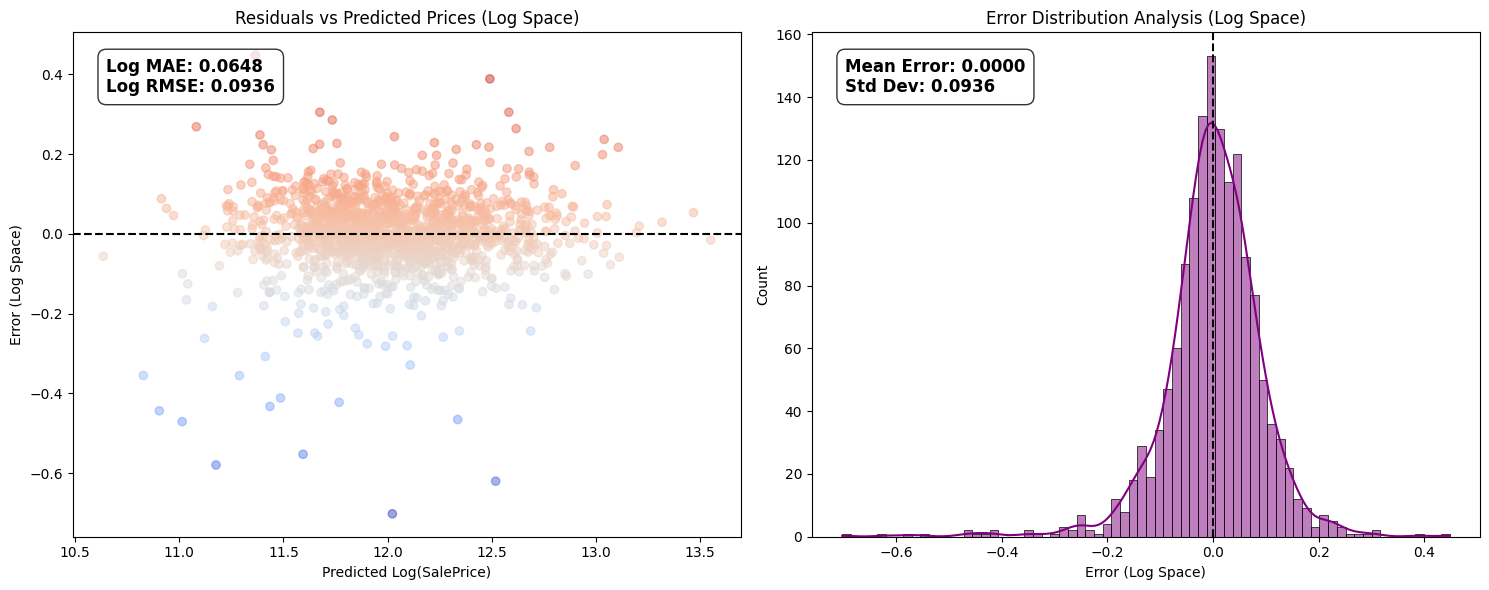

In [153]:
actual_log_prices = y_train # actual log prices for the training data
predicted_log_prices = mlp_final.predict(X_train_processed) # predictions in log space for the training data
residuals_log = actual_log_prices - predicted_log_prices # calucalte the residuals in log space (actual - predicted) to analyze the errors of the model on the training data

# We calculate MAE and RMSE in log space
mae_log = mean_absolute_error(actual_log_prices, predicted_log_prices)
rmse_log = np.sqrt(mean_squared_error(actual_log_prices, predicted_log_prices))

mean_err_log = residuals_log.mean()
std_err_log = residuals_log.std()

# This part is for visualization 
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(predicted_log_prices, residuals_log, alpha=0.5, c=residuals_log, cmap='coolwarm')
axes[0].axhline(0, color='black', linestyle='--')

stats_left = f"Log MAE: {mae_log:.4f}\nLog RMSE: {rmse_log:.4f}"
axes[0].text(0.05, 0.95, stats_left, transform=axes[0].transAxes, fontsize=12,
             verticalalignment='top', fontweight='bold', 
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

axes[0].set_title("Residuals vs Predicted Prices (Log Space)")
axes[0].set_xlabel("Predicted Log(SalePrice)")
axes[0].set_ylabel("Error (Log Space)")

sns.histplot(residuals_log, kde=True, ax=axes[1], color='purple')
axes[1].axvline(0, color='black', linestyle='--')

stats_right = f"Mean Error: {mean_err_log:.4f}\nStd Dev: {std_err_log:.4f}"
axes[1].text(0.05, 0.95, stats_right, transform=axes[1].transAxes, fontsize=12,
             verticalalignment='top', fontweight='bold', 
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

axes[1].set_title("Error Distribution Analysis (Log Space)")
axes[1].set_xlabel("Error (Log Space)")

plt.tight_layout()
plt.show()